   LigConc     STD_AF0
0      150  429.366579
1      300  505.325907
2      600  548.703550
3     1500  485.053608
4     2500  641.179733
5     4000  559.633672
580.4114435445207
50.61993955582143


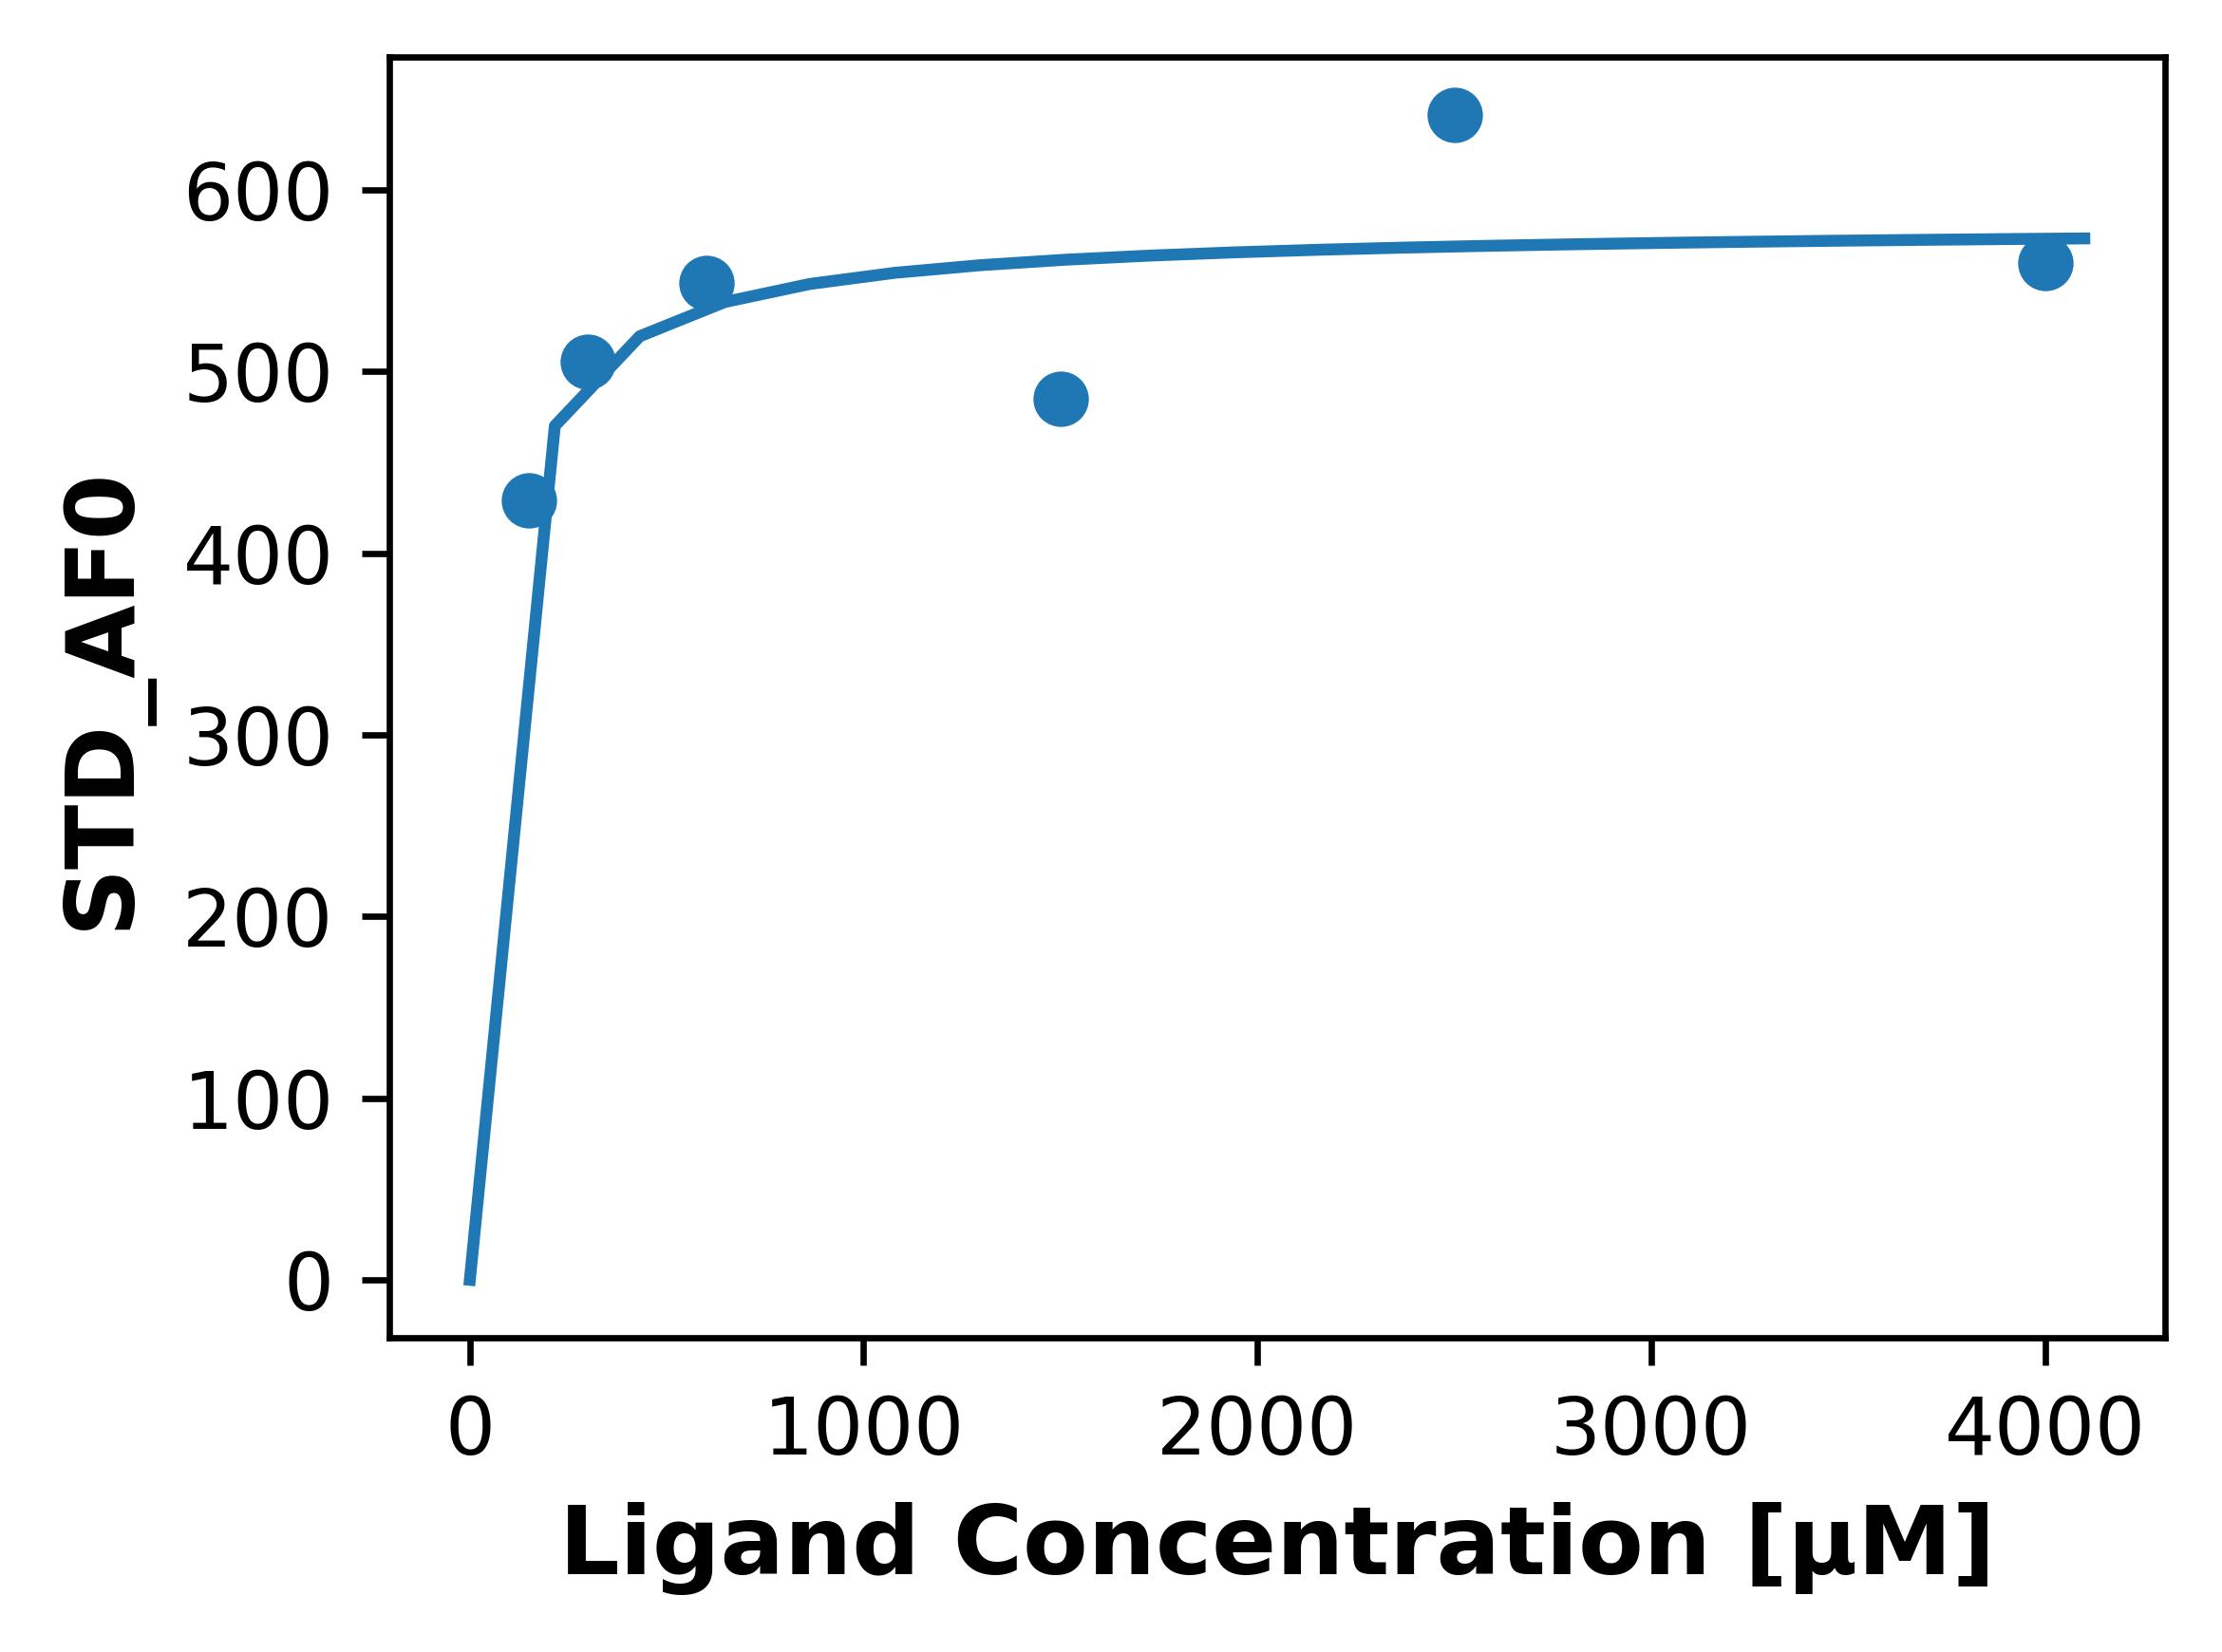

In [7]:
import streamlit as st
import st_aggrid
from st_aggrid import AgGrid, GridOptionsBuilder, JsCode
from st_aggrid.shared import GridUpdateMode
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.optimize import curve_fit

# Langmuir isotherm
def model(x,Bmax,Kd):
    return Bmax*x/(Kd+x)

tsat_short = 0.75
protconc = 20

ProtonList = ["H1", "H2", "H3"]
LigConc = [150, 300, 600, 1500, 2500, 4000]
for proton in ProtonList:

d = {'STD_short_tsat': [23.2,16.8,10.1,3.9,3,1.7],'STD_long_tsat': [30.9,28.7,21.2,10.7,7.4,4.8]}
df = pd.DataFrame(data = d)
df['ksat'] = (- np.log((df.STD_long_tsat - df.STD_short_tsat)/df.STD_long_tsat))/tsat_short
df['STD0'] = df.ksat*df.STD_long_tsat
df['Epitope'] = df.STD0/(np.max(df.STD0))*100
df['ratio'] = df.LigConc/protconc
df['STD_AF0'] = df['STD0']*df['ratio']
#df.drop(['STD_short_tsat', 'STD_long_tsat'], inplace=True, axis=1)
# Creating the STD build-up curve figure with all curves in one plot
plt.figure(figsize = (4,3), dpi=600)
X = pd.DataFrame(df,columns=["LigConc"])
Y = pd.DataFrame(df,columns=["STD_AF0"])
iso = pd.concat([X,Y], axis = 1)
print(iso)
# Plot data
plt.scatter(X, Y, marker='o')
plt.xlabel('Ligand Concentration [µM]', fontsize='12', fontstyle='normal', weight='bold')
plt.ylabel('STD_AF0', fontsize='12', fontstyle='normal', weight='bold')
#plt.xlim(0,max(iso.LigConc)+0.5)
#plt.xticks(np.arange(0,max(iso.LigConc)+0.5,1))
# Curve Fit
ans, cov = curve_fit(model, iso.LigConc, iso.STD_AF0, absolute_sigma=False, bounds=[[0,0], [2000,4000]])    
t = np.linspace(0,4100,num =20)
plt.plot(t, model(t,ans[0],ans[1]))
plt.tight_layout()
df
print(ans[0])
print(ans[1])